In [ ]:
#W7 D5  1 Feb26   Data Preprocessing & Transformation

#W8 D1  3 Feb26 (lo que falto explicar la clase anterior)

# Pandas Day 3: Data Preprocessing & Feature Engineering

## Week 3, Day 3 - Preparing Data for Machine Learning

---

### Today's Journey

| Part | Topic |
|------|-------|
| 1 | Quick Review & Duplicate Handling |
| 2 | Advanced Missing Value Strategies |
| | **BREAK 1** |
| 3 | Feature Engineering |
| 4 | Outlier Detection & Handling |
| | **BREAK 2** |
| 5 | Feature Encoding |
| 6 | Scaling & Normalization |
| 7 | Mini-Project: Complete Pipeline |

---

```
TODAY'S SCENARIO:

    ┌─────────────────────────────────────────────────────────────────────┐
    │                                                                     │
    │   Your manager walks over:                                         │
    │                                                                     │
    │   "We want to predict which passengers survived the Titanic.       │
    │    Here's the data. Build me a model by end of week."              │
    │                                                                     │
    │   You open the data and see:                                       │
    │   • Missing ages, missing cabin info                               │
    │   • Text columns like 'male'/'female', 'Southampton'               │
    │   • Names like 'Braund, Mr. Owen Harris'                           │
    │   • Fares ranging from $0 to $512                                  │
    │                                                                     │
    │   You can't feed this into a model. It will crash or give garbage.│
    │                                                                     │
    │   TODAY: You learn to transform messy data into model-ready data. │
    │                                                                     │
    └─────────────────────────────────────────────────────────────────────┘
```

```
THE TRANSFORMATION:

    RAW DATA                              MODEL-READY DATA
    ─────────                             ─────────────────
    
    age: 22, NaN, 35, NaN...        →     age_scaled: -0.53, 0.0, 0.41...
    sex: 'male', 'female'...        →     sex_encoded: 0, 1...
    embarked: 'S', 'C', 'Q'...      →     embarked_Q: 0, embarked_S: 1...
    name: 'Mr. John Smith'...       →     title_Mr: 1, title_Mrs: 0...
    fare: 7.25, 512.00, 0...        →     fare_scaled: -0.31, 2.89...
    
    
    "Data scientists spend 80% of their time on data preprocessing."
    
    Today, you learn the 80%.
```

---

# Part 1: Review & Duplicate Handling

## Starting the Preprocessing Pipeline

---

## Setup - All Imports for Today

In [87]:
# === IMPORTS ===
# pandas, numpy, seaborn, matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn imputer: SimpleImputer
from sklearn.impute import SimpleImputer

# sklearn preprocessing tools: StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)


In [6]:
# === LOAD THE DATA ===
# Load Titanic dataset from seaborn
# Save as titanic_raw - this is our ORIGINAL backup
#titanic_raw = sns.load_dataset('titanic')     #version que ya viene en la libreria seaborn.
#Son 15 columnas, No tiene nombre, y viene no duplicados


# esta version es la de Kaggle (la tengo en mi google drive)
#apta para Ingenieria de columnas, tiene 12 columnas con name y sin duplicados
titanic_raw = pd.read_csv('titanic_train.csv')


In [7]:
# === FIRST LOOK ===
# Show the first 10 rows - what does our raw data look like?
titanic_raw.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [8]:
# === ESSENTIAL WORKFLOW ===
# shape - how big is the data?
titanic_raw.shape


(891, 12)

In [9]:
# info() - what data types? what's missing?
titanic_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
# describe() - statistics for numeric columns
titanic_raw.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## The Preprocessing Pipeline

```
THE COMPLETE PREPROCESSING ORDER:

    ┌─────────────────────────────────────────────────────────────────────┐
    │                                                                     │
    │   1. DUPLICATES      → Remove exact copies                         │
    │         ↓                                                           │
    │   2. MISSING VALUES  → Fill or remove gaps                         │
    │         ↓                                                           │
    │   3. FEATURE ENG.    → Create new useful features                  │
    │         ↓                                                           │
    │   4. OUTLIERS        → Handle extreme values                       │
    │         ↓                                                           │
    │   5. ENCODING        → Convert text to numbers                     │
    │         ↓                                                           │
    │   6. SCALING         → Standardize numeric ranges                  │
    │                                                                     │
    └─────────────────────────────────────────────────────────────────────┘
    
    
    WHY THIS ORDER?
    
    • Duplicates first    → They skew all calculations
    • Missing before FE   → Can't engineer features from NaN
    • FE before outliers  → New features might have outliers too
    • Outliers before enc → Extreme values affect encoding choices
    • Encoding before sc  → Can't do math on text
    • Scaling last        → Must have clean numbers first
```

## Step 1: Duplicate Detection

```
WHY DUPLICATES ARE DANGEROUS:

    ┌─────────────────────────────────────────────────────────────────────┐
    │                                                                     │
    │   PROBLEM 1: Biased Statistics                                     │
    │   • If a row appears 10 times, it has 10x the influence            │
    │   • Your "average customer" might be one person counted 10 times  │
    │                                                                     │
    │   PROBLEM 2: Data Leakage in ML                                    │
    │   • Same record in training AND test set = cheating                │
    │   • Your model memorizes instead of learning                       │
    │                                                                     │
    │   PROBLEM 3: Wrong Business Decisions                              │
    │   • "We have 1000 customers!" (Actually 800, some duplicated)      │
    │                                                                     │
    └─────────────────────────────────────────────────────────────────────┘
```

In [11]:
# === STEP 1: CHECK FOR DUPLICATES ===
# Create working copy:
df = titanic_raw.copy()

# Count duplicates:

print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [12]:
# === EXAMPLE: What duplicates look like ===
duplicated_df = df[df.duplicated(keep=False)]
duplicated_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [13]:
#duplicated_df.sort_values(['pclass', 'who']).head(20)

In [14]:
# === REMOVE DUPLICATES ===
# Use drop_duplicates()
# Show before/after row counts

duplicated_df = duplicated_df.drop_duplicates()  #solo los duplicados
duplicated_df.shape     #(0, 12)


(0, 12)

In [15]:
# Show before/after row counts
df = df.drop_duplicates()  #ahora sin los duplicados
df.shape   #(784, 15)   #(891, 12)

(891, 12)

In [16]:
# === DUPLICATES ON SPECIFIC COLUMNS ===
# Check duplicates on subset of columns
# Keep first or last occurrence

df.duplicated(subset=['Age']).sum()

np.int64(802)

## Duplicate Handling Cheat Sheet

| What you need | Code |
|---------------|------|
| Count duplicates | `df.duplicated().sum()` |
| View all duplicates | `df[df.duplicated(keep=False)]` |
| Remove duplicates | `df.drop_duplicates()` |
| Check specific columns | `df.duplicated(subset=['col1', 'col2'])` |
| Keep first/last | `df.drop_duplicates(keep='first')` or `keep='last'` |

---

# Part 2: Advanced Missing Value Strategies

## Building on Day 2 - Professional Techniques

---

In [17]:
# === STEP 2: MISSING VALUE ANALYSIS ===
# Count missing values: df.isnull().sum()
# Calculate missing percentage
# Display only columns with missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame(
    {
        'Missing Count': missing_counts,
        'Missing %': missing_pct
    }
)

missing_df[missing_df['Missing Count'] > 0]


,Missing Count,Missing %
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


## The Missing Value Decision Framework

```
HOW TO DECIDE WHAT TO DO:

    ┌──────────────────────────────────────────┐
    │         How much is missing?             │
    └─────────────────────┬────────────────────┘
                          │
            ┌─────────────┼─────────────┐
            │             │             │
         > 50%        5-50%          < 5%
            │             │             │
            ▼             ▼             ▼
      DROP COLUMN    IMPUTE        DROP ROWS
      (too sparse)   (fill it)     (minimal loss)
                        │
                   ┌────┴────┐
                   │         │
                Numeric  Categorical
                   │         │
                   ▼         ▼
              MEDIAN      MODE
           (or group    (most common)
            median)


    OUR TITANIC DATA:
    
    • deck (77%)     → DROP COLUMN (too much missing)
    • age (20%)      → IMPUTE with median (or group median)
    • embarked (0.2%) → IMPUTE with mode (most common port)
```

In [18]:
# === STEP 2a: DROP SPARSE COLUMNS ===
# Drop 'Cabin' column (77% missing)
# df.drop(columns=['Cabin'])

# print(f"Number of columns BEFORE dropping: {len(df.columns)}")
#df = df.drop(columns=['Cabin'])
# print(f"Number of columns AFTER dropping: {len(df.columns)}")

df.columns
# Drop 'Cabin' column (77% missing)
df.drop(columns=['Cabin'])

print(f"Number of columns BEFORE dropping: {len(df.columns)}")
df = df.drop(columns=['Cabin'])
print(f"Number of columns AFTER dropping: {len(df.columns)}")


Number of columns BEFORE dropping: 12
Number of columns AFTER dropping: 11


## SimpleImputer: The Professional Approach

```
WHY USE SimpleImputer INSTEAD OF fillna()?

    fillna() is great for quick exploratory work.
    
    SimpleImputer is better for production ML because:
    
    1. CONSISTENCY: It remembers the value it calculated
       → You fit on training data, transform test data with SAME value
    
    2. PIPELINES: It integrates with scikit-learn pipelines
       → Your preprocessing becomes reproducible and deployable
    
    3. OPTIONS: Built-in strategies
       → 'mean', 'median', 'most_frequent', 'constant'
```

In [19]:
# === STEP 2b: FILL AGE WITH SIMPLEIMPUTER ===
# Create imputer with strategy='median'
# Apply fit_transform to age column
# Check imputer.statistics_ to see value used
print(f"Age missing before: {df['Age'].isnull().sum()}")

age_imputer = SimpleImputer(strategy='median')
df['Age'] = age_imputer.fit_transform(df[['Age']])

print(f" Median age used: {age_imputer.statistics_[0]}")
print(f"Age missing after: {df['Age'].isnull().sum()}")

Age missing before: 177
 Median age used: 28.0
Age missing after: 0


In [20]:
#explicacion de porque usa median y no mean
ages = [20, 25, 30, 35, 100]
print(np.mean(ages))
print(np.median(ages))

42.0
30.0


## Advanced: Group-Specific Imputation

Sometimes the overall median isn't the best choice. Different groups might have different typical values.

In [21]:
# === GROUP IMPUTATION DEMO ===
# Show median age by passenger class (from original data)


titanic_raw.groupby('Pclass')['Age'].median()

,Age
Pclass,
1,37.0
2,29.0
3,24.0


In [22]:
# === GROUP IMPUTATION PATTERN ===
# Pattern: df.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))
# This fills each missing value with median of its GROUP
df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [23]:
df.columns
df['Embarked'].mode()[0]


'S'

In [24]:
# === STEP 2c: FILL CATEGORICAL COLUMNS ===
# Fill embarked and embark_town with mode (most common value)
# df['col'].mode()[0] gives most frequent value

print(f"Embarked missing before: {df['Embarked'].isnull().sum()}")
#print(f"Embarked Town missing before: {df['embark_town'].isnull().sum()}")

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

print(f"Embarked missing after: {df['Embarked'].isnull().sum()}")
#print(f"Embarked Town missing after: {df['embark_town'].isnull().sum()}")

Embarked missing before: 2
Embarked missing after: 0


In [25]:
# === VERIFY: No Missing Values ===
# Check remaining missing values
#df.isnull().sum()
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


---

## BREAK 1

### What we've covered:
- The 6-step preprocessing pipeline (memorize this order!)
- Duplicate detection and removal
- Missing value strategies: drop, impute with median/mode, group imputation
- SimpleImputer for production ML pipelines

### Coming up after break:
- **Feature Engineering** - Creating powerful new features from existing data

---

---

# Part 3: Feature Engineering

## Creating New Information from Existing Data

---

## Feature 1: Family Size

In [26]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [27]:
# === STEP 3: FEATURE ENGINEERING ===
# Look at family columns: sibsp (siblings/spouses) and parch (parents/children)
df[['SibSp', 'Parch']].head(10)

,SibSp,Parch
0,1,0
1,1,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,3,1
8,0,2
9,1,0


In [28]:
# === CREATE FAMILY_SIZE ===
# family_size = sibsp + parch + 1 (include the passenger)
# Check the distribution
df['family_size'] = df['SibSp'] + df['Parch'] + 1

df['family_size'].value_counts().sort_index()

,count
family_size,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


In [29]:
# === THE PAYOFF: Survival by Family Size ===
# df.groupby('family_size')['survived'].mean()
# What patterns do you see?

survival_by_family = ( df.groupby('family_size')['Survived'].mean().mul(100).round(2) )

survival_by_family
# Quienes viajan con familia de tamanio 2, 3, 4 tienen tasas de sobrevivencia mas alta (vs viajar solo o en familias mas grandes)

,Survived
family_size,
1,30.35
2,55.28
3,57.84
4,72.41
5,20.00
6,13.64
7,33.33
8,0.00
11,0.00


In [30]:
# === CREATE IS_ALONE ===
# Binary feature: 1 if family_size == 1, else 0
# Compare survival rates: alone vs with family

df['is_alone'] = (df['family_size'] == 1).astype(int)

print(f"Alone: {df[df['is_alone'] == 1]['Survived'].mean()*100}%")
print(f"With Family: {df[df['is_alone'] == 0]['Survived'].mean()*100}%")

survival_alone = ( df.groupby('is_alone')['Survived'].mean() . mul(100).round(2) )

survival_alone

# Quienes viajan con familia tienen mayor tasa de sobrevivencia (vs quienes viajan solos). Es mejor viajar con alguien.

Alone: 30.353817504655495%
With Family: 50.56497175141242%


,Survived
is_alone,
0,50.56
1,30.35


In [ ]:
# # Crear mapping
# alone_mapping = {0: 'No', 1: 'Yes'}

# # Aplicar mapping
# df['is_alone_str'] = df['is_alone'].map(alone_mapping)

# # Ver resultado
# print(df[['is_alone', 'is_alone_str']].head())


   is_alone is_alone_str
0         0           No
1         0           No
2         1          Yes
3         0           No
4         1          Yes


## Feature 2: Extracting Title from Name

In [31]:
# === LOOK AT NAME COLUMN ===
# Pattern: "Lastname, Title. Firstname"
# What titles can you spot?
df['Name'].head(10)


,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
5,"Moran, Mr. James"
6,"McCarthy, Mr. Timothy J"
7,"Palsson, Master. Gosta Leonard"
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)"
9,"Nasser, Mrs. Nicholas (Adele Achem)"


In [32]:
# === EXTRACT TITLE WITH REGEX ===
# df['name'].str.extract(r',\s*([^.]+)\.')
# Check value_counts() of extracted titles

df['title'] = df['Name'].str.extract(r',\s*([^.]+)\.')

df['title'].value_counts()

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [33]:
# === SIMPLIFY TITLES ===
# Create mapping: common titles stay, rare ones become 'Rare'
# Mlle → Miss, Mme → Mrs

title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    # map rare/foreign titles
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Mlle': 'Miss',
    'Major': 'Rare',
    'Ms': 'Mrs',
    'Mme': 'Mrs',
    'Don': 'Rare',
    'Lady': 'Rare',
    'Sir': 'Rare',
    'Capt': 'Rare',
    'the Countess': 'Rare',
    'Jonkheer': 'Rare'
}

df['title'] = df['title'].map(title_mapping)
df['title'].value_counts()

,count
title,
Mr,517
Miss,184
Mrs,127
Master,40
Rare,23


In [34]:
# === THE PAYOFF: Survival by Title ===
# df.groupby('title')['survived'].mean()
# Which titles had best/worst survival?

survival_by_title = (df.groupby('title')['Survived'].mean() .mul(100) . round (2))

survival_by_title
#mujeres y ninios con tasa de supervivencia mas alta, mujeres y ninios primero

,Survived
title,
Master,57.50
Miss,70.11
Mr,15.67
Mrs,79.53
Rare,34.78


## Feature 3: Age Groups with pd.cut()

In [35]:
# === CREATE AGE GROUPS ===
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Middle Aged', 'Senior']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [36]:
# === SURVIVAL BY AGE GROUP ===
survival_by_age = (df.groupby('age_group')['Survived'].mean() .mul(100) . round (2))
survival_by_age
#ninios y adolescentes tienen mejores tasas de sobrevivencia que los mas grandes


/tmp/ipython-input-1504658371.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = (df.groupby('age_group')['Survived'].mean() .mul(100) . round (2))


,Survived
age_group,
Child,57.97
Teen,42.86
Young Adult,35.33
Middle Aged,40.00
Senior,22.73


## Feature Engineering Summary

```
COMMON FEATURE ENGINEERING TECHNIQUES:

    ┌─────────────────────────────────────────────────────────────────────┐
    │ TECHNIQUE           │ EXAMPLE                                      │
    ├─────────────────────┼──────────────────────────────────────────────┤
    │ Combine columns     │ family_size = sibsp + parch + 1              │
    │ Extract from text   │ title = extract from name with regex         │
    │ Bin continuous      │ age_group = pd.cut(age, bins, labels)        │
    │ Binary indicator    │ is_alone = (family_size == 1)                │
    │ Mathematical        │ fare_per_person = fare / family_size         │
    │ Date extraction     │ month = date.dt.month, day_of_week           │
    └─────────────────────┴──────────────────────────────────────────────┘
    
    
    THE KEY INSIGHT:
    
    Feature engineering is where DOMAIN KNOWLEDGE meets DATA.
```

---

# Part 4: Outlier Detection and Handling

## Finding and Treating Extreme Values

---

STEP 4: Outlier Detection and Handling


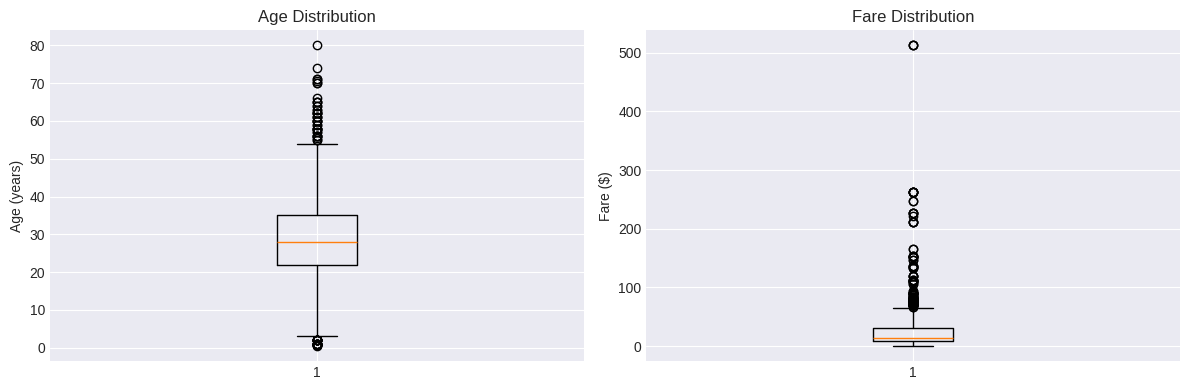


Boxplot interpretation:
  Box = middle 50% of data (Q1 to Q3)
  Line in box = median
  Whiskers = 1.5 × IQR from box
  Dots outside whiskers = OUTLIERS


In [38]:
# STEP 4: Outlier Detection
print("STEP 4: Outlier Detection and Handling")
print("=" * 40)

# Visualize distributions with boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Age'].dropna())
axes[0].set_title('Age Distribution')
axes[0].set_ylabel('Age (years)')

axes[1].boxplot(df['Fare'].dropna())
axes[1].set_title('Fare Distribution')
axes[1].set_ylabel('Fare ($)')

plt.tight_layout()
plt.show()

print("\nBoxplot interpretation:")
print("  Box = middle 50% of data (Q1 to Q3)")
print("  Line in box = median")
print("  Whiskers = 1.5 × IQR from box")
print("  Dots outside whiskers = OUTLIERS")

In [40]:
# === EXAMINE FARE OUTLIERS ===
# Show fare statistics with describe()
# Show top 10 highest fares

print(df['Fare'].describe())

print(df.nlargest(20, 'Fare')[['Name', 'Pclass', 'Fare']])      #hay varios registros de super lujo, desestabilizan la distribucion de Fare


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64
                                                  Name  Pclass      Fare
258                                   Ward, Miss. Anna       1  512.3292
679                 Cardeza, Mr. Thomas Drake Martinez       1  512.3292
737                             Lesurer, Mr. Gustave J       1  512.3292
27                      Fortune, Mr. Charles Alexander       1  263.0000
88                          Fortune, Miss. Mabel Helen       1  263.0000
341                     Fortune, Miss. Alice Elizabeth       1  263.0000
438                                  Fortune, Mr. Mark       1  263.0000
311                         Ryerson, Miss. Emily Borie       1  262.3750
742              Ryerson, Miss. Susan Parker "Suzette"       1  262.3750
118                           Baxter, Mr. Quigg Edmond       1  247.5208
299    Bax

## The IQR Method for Outlier Detection

```
IQR (INTERQUARTILE RANGE) METHOD:

    Q1 = 25th percentile (25% of data is below this)
    Q3 = 75th percentile (75% of data is below this)
    IQR = Q3 - Q1        (the "middle 50%" range)
    
    Lower bound = Q1 - 1.5 × IQR
    Upper bound = Q3 + 1.5 × IQR
    
    Anything OUTSIDE these bounds = OUTLIER
```

In [41]:
# === CALCULATE IQR FOR FARE ===
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
# Calculate upper/lower bounds
# Count outliers

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1}")
print(f"Q3 (75th percentile): ${Q3}")
print(f"IQR: ${IQR}")

print(f"Lower bound: ${lower_bound}")
print(f"Upper bound: ${upper_bound}")

outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(f"Outliers detected: {len(outliers)/len(df) * 100:.1f}% of data")  #--> cuanto pesan los outliers en mi distribucion?

Q1 (25th percentile): $7.9104
Q3 (75th percentile): $31.0
IQR: $23.0896
Lower bound: $-26.724
Upper bound: $65.6344
Outliers detected: 13.0% of data


## Handling Outliers: Three Options

```
WHAT TO DO WITH OUTLIERS:

    OPTION 1: REMOVE      → Delete rows (lose data)
    OPTION 2: CAP         → Replace with threshold (keep rows)
    OPTION 3: TRANSFORM   → Apply log/sqrt (reduce skew)
```

In [42]:
# === CAP OUTLIERS AT 98TH PERCENTILE ===
fare_cap = df['Fare'].quantile(0.98)   #pone un limite y "reemplaza " todo lo que supere el Q(98)

outliers_count = (df['Fare'] > fare_cap).sum()

print(f"Capping fare at 98th percentile: ${fare_cap}")
print(f"Values to be capped: {outliers_count}")
print("Before capping")
print(f"Max fare: ${df['Fare'].max()}")


df['Fare'] = df['Fare'].clip(upper=fare_cap)
# Show before/after max values
print("After capping")
print(f"Max fare: ${df['Fare'].max()}")

Capping fare at 98th percentile: $211.3375
Values to be capped: 17
Before capping
Max fare: $512.3292
After capping
Max fare: $211.3375


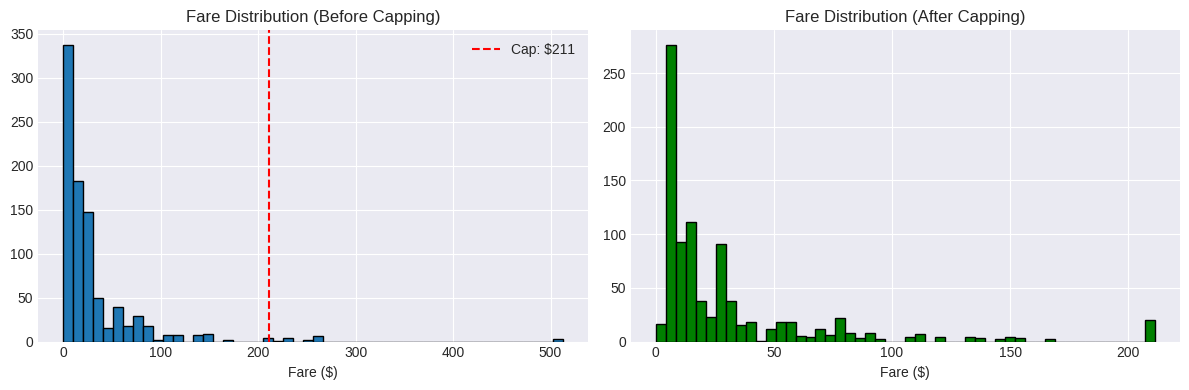

The extreme right tail has been capped - no more $500+ fares distorting our analysis.


In [43]:
# Visualize the effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before (from original data)
axes[0].hist(titanic_raw['Fare'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Fare Distribution (Before Capping)')
axes[0].set_xlabel('Fare ($)')
axes[0].axvline(x=fare_cap, color='red', linestyle='--', label=f'Cap: ${fare_cap:.0f}')
axes[0].legend()

# After
axes[1].hist(df['Fare'].dropna(), bins=50, edgecolor='black', color='green')
axes[1].set_title('Fare Distribution (After Capping)')
axes[1].set_xlabel('Fare ($)')

plt.tight_layout()
plt.show()

print("The extreme right tail has been capped - no more $500+ fares distorting our analysis.")

## When NOT to Remove Outliers

```
CAUTION: Outliers aren't always bad!

    DON'T remove outliers when:
    
    • They're real and important (fraud detection! Rare disesase)
    • Your sample is small
    • They represent a meaningful subgroup
    
    ALWAYS ASK: "Is this outlier telling me something important?"
```

---

## BREAK 2

### What we've covered:
- Feature Engineering: family_size, is_alone, title, age_group
- Outlier Detection: boxplots, IQR method
- Outlier Handling: cap vs remove vs transform

### Coming up after break:
- **Feature Encoding** - Converting text to numbers
- **Scaling** - Putting features on the same scale

---

---

# Part 5: Feature Encoding

## Converting Categories to Numbers

---

## Two Encoding Strategies

```
LABEL ENCODING:
───────────────
    'Male'   → 0
    'Female' → 1
    
    ✓ Simple, one column stays one column
    ✗ DANGER: Implies ordering! (1 > 0)
    
    USE FOR: Binary variables, Ordinal variables
    

ONE-HOT ENCODING:
─────────────────
    'C' → embarked_C=1, embarked_Q=0, embarked_S=0
    'Q' → embarked_C=0, embarked_Q=1, embarked_S=0
    'S' → embarked_C=0, embarked_Q=0, embarked_S=1
    
    ✓ No implied ordering
    ✗ Creates many columns
    
    USE FOR: Nominal variables with 3+ unordered categories
```

In [45]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'family_size', 'is_alone',
       'title', 'age_group'],
      dtype='object')

In [106]:
# === STEP 5: IDENTIFY CATEGORICAL COLUMNS ===
# What categorical columns do we need to encode?
# one-hot encoding = embarked, title
# label encoding = sex, age_group

print('one-hot encoding')
print(f"embarked: {df['Embarked'].unique()}")   #need to encode
print(f"title: {df['title'].unique()}")  #need to encode

print('\nlabel encoding')
print(f"sex: {df['Sex'].unique()}")   #need to encode
print(f"age_group: {df['age_group'].unique()}")   #need to encode

print(f"\nis_alone: {df['is_alone'].unique()}")  # a este solo ponerle la etiqueta yes-no
print(f"Pclass': {df['Pclass'].unique()}")
print(f"family_size': {df['family_size'].unique()}")





one-hot encoding
embarked: ['S' 'C' 'Q']
title: ['Mr' 'Mrs' 'Miss' 'Master' 'Rare']

label encoding
sex: ['male' 'female']
age_group: ['Young Adult', 'Middle Aged', 'Child', 'Teen', 'Senior']
Categories (5, object): ['Child' < 'Teen' < 'Young Adult' < 'Middle Aged' < 'Senior']

is_alone: [0 1]
Pclass': [3 1 2]
family_size': [ 2  1  5  3  7  6  4  8 11]


In [50]:
# === ONE-HOT ENCODE EMBARKED ===
# pd.get_dummies(df['embarked'], prefix='embarked', drop_first=True)  no va con drop_first true xq te crea k-1 columnas, no k, siendo k las categorias
  # Concatenate with main dataframe

embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked').astype(int)
embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [56]:
# Add one-hot columns to our dataframe

df = pd.concat([df, embarked_dummies], axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,age_group,sex_encoded,is_alone_str,Embarked_C,Embarked_Q,Embarked_S,age_group_encoded,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,Young Adult,0,No,0,0,1,2,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,Middle Aged,1,No,1,0,0,3,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,Young Adult,1,Yes,0,0,1,2,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,Young Adult,1,No,0,0,1,2,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,Young Adult,0,Yes,0,0,1,2,0,0,1


In [59]:
# === ONE-HOT ENCODE TITLE ===
title_dummies = pd.get_dummies(df['title'], prefix='title').astype(int)
title_dummies.head()



,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare
0,0,0,1,0,0
1,0,0,0,1,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,1,0,0


In [60]:
# Add one-hot columns to our dataframe

df = pd.concat([df, title_dummies], axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,is_alone_str,Embarked_C,Embarked_Q,Embarked_S,age_group_encoded,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,No,0,0,1,2,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,No,1,0,0,3,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,Yes,0,0,1,2,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,No,0,0,1,2,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,Yes,0,0,1,2,0,0,1,0,0


In [48]:
# === LABEL ENCODE SEX ===
# Binary - use map({'male': 0, 'female': 1})
sex_mapping = {'male': 0, 'female': 1}

df['sex_encoded'] = df['Sex'].map(sex_mapping)

print(df[['Sex', 'sex_encoded']].head())


      Sex  sex_encoded
0    male            0
1  female            1
2  female            1
3  female            1
4    male            0


In [65]:
# label encoding de age_group (tiene categorías ordenadas):
df['age_group'].unique()

# ['Young Adult', 'Middle Aged', 'Child', 'Teen', 'Senior']
#Categories (5, object): ['Child' < 'Teen' < 'Young Adult' < 'Middle Aged' < 'Senior']

df['age_group'] = pd.Categorical(
      df['age_group'],
      categories=['Child', 'Teen', 'Young Adult', 'Middle Aged', 'Senior'],
      ordered=True
  )

 # # Label encoding
df['age_group_encoded'] = df['age_group'].cat.codes

print(df[['age_group', 'age_group_encoded']].head())

     age_group  age_group_encoded
0  Young Adult                  2
1  Middle Aged                  3
2  Young Adult                  2
3  Young Adult                  2
4  Young Adult                  2


In [107]:
# # === elimina las columnas que hayan podido quedar duplicadas  ===
df = df.loc[:, ~df.columns.duplicated()].copy()


In [108]:
# === STEP 5 COMPLETE ===
# Print summary of encoding done
# Check new column count

print({len(df.columns)})
df.head()




{28}


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_Q,Embarked_S,age_group_encoded,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare,age_scaled,fare_scaled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,1,2,0,0,1,0,0,-0.565736,-0.587437
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,0,3,0,0,0,1,0,0.663861,1.018110
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0,1,2,0,1,0,0,0,-0.258337,-0.570512
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0,1,2,0,0,0,1,0,0.433312,0.562189
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,1,2,0,0,1,0,0,0.433312,-0.567378


## When NOT to One-Hot Encode

```
CAUTION: One-Hot Encoding has limits!

    Problem: HIGH CARDINALITY (1000+ unique categories = 1000 columns!)
    
    ALTERNATIVES:
    1. Group rare categories into 'Other'
    2. Target encoding
    3. Frequency encoding
    
    RULE OF THUMB: If >10-15 categories, consider alternatives.
```

---

# Part 6: Scaling and Normalization

## Putting All Features on the Same Scale

---

In [72]:
# === STEP 6: CHECK CURRENT SCALES ===
# Print min, max, mean for age and fare
# Are they on the same scale? nooooooo

print(f'Stats Age: min = {df['Age'].min()} ; max = {df['Age'].max()} ; mean = {df['Age'].mean()}')
print(f'Stats Fare: min = {df['Fare'].min()} ; max = {df['Fare'].max()} ; mean = {df['Fare'].mean()}')



Stats Age: min = 0.42 ; max = 80.0 ; mean = 29.36158249158249
Stats Fare: min = 0.0 ; max = 211.3375 ; mean = 30.678483052749723


## Two Scaling Methods

```
STANDARD SCALER (Z-score normalization):
────────────────────────────────────────
    Formula: z = (x - mean) / std
    Result:  mean = 0, std = 1
    USE FOR: Most ML algorithms


MIN-MAX SCALER:
───────────────
    Formula: x_scaled = (x - min) / (max - min)
    Result:  all values in range [0, 1]
    USE FOR: Neural networks, images
```

In [88]:
# === APPLY STANDARDSCALER to AGe ===
# scaler = StandardScaler()

# df['age_scaled'] = scaler.fit_transform(df[['Age']])

# # === APPLY STANDARDSCALER to Fare ===

# df['fare_scaled'] = scaler.fit_transform(df[['Fare']])



# aca lo hago juntos
scaler = StandardScaler()
df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['Age', 'Fare']])




In [90]:
# === VERIFY SCALING ===
# Check mean and std of scaled columns

print("Age Scaled")
print(f"Mean: {df['age_scaled'].mean():.10f}")
print(f"Std:  {df['age_scaled'].std():.10f}")

print("\nFare Scaled")
print(f"Mean: {df['fare_scaled'].mean():.10f}")
print(f"Std:  {df['fare_scaled'].std():.10f}")



Age Scaled
Mean: 0.0000000000
Std:  1.0005616400

Fare Scaled
Mean: -0.0000000000
Std:  1.0005616400


In [91]:
# === VERIFY SCALING ===

# Compare original vs scaled values
df[['age_scaled', 'Age' , 'fare_scaled', 'Fare']].head()


,age_scaled,Age,fare_scaled,Fare
0,-0.565736,22.0,-0.587437,7.2500
1,0.663861,38.0,1.018110,71.2833
2,-0.258337,26.0,-0.570512,7.9250
3,0.433312,35.0,0.562189,53.1000
4,0.433312,35.0,-0.567378,8.0500


## Scaling Summary

| Scaler | Formula | Result | Use When |
|--------|---------|--------|----------|
| StandardScaler | `(x - mean) / std` | mean=0, std=1 | Most ML algorithms |
| MinMaxScaler | `(x - min) / (max - min)` | [0, 1] range | Neural nets, images |

**Important**: Always scale AFTER handling outliers!

---

# Part 7: Final Assembly - Model-Ready Data

## Selecting Features and Before/After Comparison

---

In [94]:
# === SELECT FINAL FEATURES ===
# Choose features for our model:
# survived, pclass, sex_encoded, age_scaled, fare_scaled
# family_size, is_alone
# One-hot columns for embarked, title, age_group

df.columns

feature_columns = [
  'Survived',
  'Pclass',
  'sex_encoded',
  'age_group_encoded',
  'age_scaled', # el profe no la agrego, creo que se olvido
  'fare_scaled',
  'family_size',
  'is_alone',
#One - Hot Encoded
  'Embarked_C',
  'Embarked_Q',
  'Embarked_S',
  'title_Master',
  'title_Miss',
  'title_Mr',
  'title_Mrs',
  'title_Rare'
]

#df final for machine learning
df_final = df[feature_columns].copy()



In [ ]:
# === BEFORE vs AFTER ===
# Show raw data sample
# Show processed data sample
# Compare shapes, missing values, data types


In [100]:
# === FINAL VERIFICATION ===
# Rows, features, missing values
# All numeric? Ready for ML?

df_final.head()

,Survived,Pclass,sex_encoded,age_group_encoded,age_scaled,fare_scaled,family_size,is_alone,Embarked_C,Embarked_Q,Embarked_S,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare
0,0,3,0,2,-0.565736,-0.587437,2,0,0,0,1,0,0,1,0,0
1,1,1,1,3,0.663861,1.018110,2,0,1,0,0,0,0,0,1,0
2,1,3,1,2,-0.258337,-0.570512,1,1,0,0,1,0,1,0,0,0
3,1,1,1,2,0.433312,0.562189,2,0,0,0,1,0,0,0,1,0
4,0,3,0,2,0.433312,-0.567378,1,1,0,0,1,0,0,1,0,0


In [102]:

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Survived           891 non-null    int64  
 1   Pclass             891 non-null    int64  
 2   sex_encoded        891 non-null    int64  
 3   age_group_encoded  891 non-null    int8   
 4   age_scaled         891 non-null    float64
 5   fare_scaled        891 non-null    float64
 6   family_size        891 non-null    int64  
 7   is_alone           891 non-null    int64  
 8   Embarked_C         891 non-null    int64  
 9   Embarked_Q         891 non-null    int64  
 10  Embarked_S         891 non-null    int64  
 11  title_Master       891 non-null    int64  
 12  title_Miss         891 non-null    int64  
 13  title_Mr           891 non-null    int64  
 14  title_Mrs          891 non-null    int64  
 15  title_Rare         891 non-null    int64  
dtypes: float64(2), int64(13), 

---

# Mini-Project: Build Your Own Pipeline

Now practice building the complete pipeline from scratch.

---

## The Challenge

```
YOUR TASK:

    Starting with: Raw Titanic dataset (fresh load)
    Ending with: Clean, model-ready data
    
    Follow the 6 steps:
    
    1. Check for duplicates
    2. Handle missing values (drop deck, fill age/embarked)
    3. Engineer features (family_size, title)
    4. Handle outliers (cap fare)
    5. Encode categoricals (sex, embarked, title)
    6. Scale numerics (age, fare)
    
    Write clean, commented code.
    Verify your final result has no missing values.
```

In [ ]:
# === YOUR COMPLETE PIPELINE ===

# Step 1: Duplicates

# Step 2: Missing Values

# Step 3: Feature Engineering

# Step 4: Outliers

# Step 5: Encoding

# Step 6: Scaling

# Final verification


---

# Wrap Up

---

## Today's Key Patterns - Quick Reference

```python
# THE PIPELINE ORDER
# 1. Duplicates → 2. Missing → 3. Features → 4. Outliers → 5. Encoding → 6. Scaling

# DUPLICATES
df.duplicated().sum()           # Count
df.drop_duplicates()            # Remove

# MISSING VALUES
df['col'].fillna(median)        # Quick
SimpleImputer(strategy='median') # Production

# FEATURE ENGINEERING
df['new'] = df['a'] + df['b']                    # Combine
df['title'] = df['name'].str.extract(pattern)    # Extract
pd.cut(df['age'], bins, labels)                  # Bin

# OUTLIERS
Q1, Q3 = df['col'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df['col'].clip(upper=threshold)  # Cap

# ENCODING
df['col'].map({'a': 0, 'b': 1})     # Label (binary)
pd.get_dummies(df['col'])            # One-hot (nominal)

# SCALING
StandardScaler().fit_transform(df[['col']])
```

## Practice Exercises

See the separate **day3_exercises.ipynb** notebook for hands-on practice:

1. **Exercise 1**: Duplicate Detection and Removal
2. **Exercise 2**: Handling Missing Values with SimpleImputer
3. **Exercise 3**: Feature Engineering (Family Size, Title)
4. **Exercise 4**: Outlier Detection with IQR and Z-score
5. **Exercise 5**: Data Standardization and Normalization
6. **Exercise 6**: Feature Encoding (Label and One-Hot)
7. **Exercise 7**: Age Groups with pd.cut()

**Bonus**: Complete the full pipeline on a fresh dataset